In [4]:
# ==============================================================
# Cell 1 — Imports & config
# ==============================================================
from pathlib import Path
import numpy as np
import laspy
import yaml
import pandas as pd
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
from IPython.display import display

# ------------------------------------------------------------
# USER CONFIG
# ------------------------------------------------------------

# Fichier YAML des LCP pointés dans le nuage MLS avec dérive
LCP_YAML = Path("/home/b085164/PDM_Romain_Defferrard/ECCR/LV95/blocs_GCP/lcp_outage.yml")

# Dossier contenant les blocs MLS ajustés sur GCP (nuages de référence)
REF_BLOCS_DIR = Path("/home/b085164/PDM_Romain_Defferrard/ECCR/LV95/blocs_GCP")

# Dossier contenant les nuages MLS avec dérive (outage)
# Dossiers à comparer
# AIRINS
DIRS = {
    "Outage":   Path("/media/b085164/LaCie/2026spring_RD/ECCR/georef_ALL_zone_3_outage/merged/ALL"),
#    "F2B":      Path("/media/b085164/LaCie/2026spring_RD/ECCR/georef_ALL_zone_3_outage/georef_F2B/merged/ALL"),
#    "Combined": Path("/media/b085164/LaCie/2026spring_RD/ECCR/georef_ALL_zone_3_outage/georef_COMBINED/merged/ALL"),
}

# APX
# DIRS = {
#     "Outage":   Path("/media/b085164/LaCie/2026spring_RD/ECCR/georef_ALL_zone_3_outage/APX/merged/ALL"),
#     "F2B":      Path("/media/b085164/LaCie/2026spring_RD/ECCR/georef_ALL_zone_3_outage/APX/georef_F2B/merged/ALL"),
#     "Combined": Path("/media/b085164/LaCie/2026spring_RD/ECCR/georef_ALL_zone_3_outage/APX/georef_COMBINED/merged/ALL"),
# }
# Rayon de recherche densité (m) et tolérance Z (m)
DENSITY_RADIUS = 0.15
DENSITY_DZ     = 0.05

# scanner_src VUX
VUX_SRC = 2

In [5]:
# ==============================================================
# Cell 2 — Charger les LCP depuis le YAML
# ==============================================================

with open(LCP_YAML, "r") as f:
    lcp_raw = yaml.safe_load(f)

lcps = pd.DataFrame(lcp_raw["lcps"])
lcps = lcps.set_index("id")

print(f"{len(lcps)} LCPs chargés\n")
display(lcps)

8 LCPs chargés



,description,gps_time,x,y,z
id,,,,,
LCP01,marquage sol,315659.459576,2.533286e+06,1.155104e+06,462.988007
LCP02,bouche egout,315712.474327,2.533259e+06,1.155030e+06,462.362000
LCP03,bouche egout,315742.343422,2.533259e+06,1.155030e+06,462.389008
LCP04,marquage sol,315761.046630,2.533263e+06,1.155090e+06,463.408997
LCP05,lampadaire pied,315810.311700,2.533227e+06,1.155117e+06,463.656006
LCP06,marquage sol coin,315822.334268,2.533238e+06,1.155167e+06,464.398987
LCP07,marquage sol coin,316057.153545,2.533239e+06,1.155169e+06,464.015015
LCP08,bouche egout,315842.746895,2.533265e+06,1.155193e+06,464.609009


In [6]:
def find_all_lcps_in_file(las_path: Path, gps_times: dict,
                           tol_t: float = 0.5) -> dict:
    """
    Cherche tous les LCP en une seule lecture du fichier.
    gps_times : {lcp_id: gps_time}
    Retourne {lcp_id: {"xyz_found", "gps_time_found", "dt", "file"}} 
    pour les LCP trouvés uniquement.
    """
    results = {}
    gps_arr = np.array(list(gps_times.values()))
    lcp_ids = list(gps_times.keys())

    with laspy.open(las_path) as f:
        for chunk in f.chunk_iterator(10_000_000):
            t = np.asarray(chunk.gps_time, dtype=np.float64)
            x = np.asarray(chunk.x, dtype=np.float64)
            y = np.asarray(chunk.y, dtype=np.float64)
            z = np.asarray(chunk.z, dtype=np.float64)

            for lcp_id, gps_t in zip(lcp_ids, gps_arr):
                if lcp_id in results and results[lcp_id]["dt"] == 0.0:
                    continue  # déjà trouvé exactement
                mask_t = np.abs(t - gps_t) < tol_t
                if not np.any(mask_t):
                    continue
                idx = np.argmin(np.abs(t[mask_t] - gps_t))
                dt  = float(np.abs(t[mask_t][idx] - gps_t))
                if lcp_id not in results or dt < results[lcp_id]["dt"]:
                    results[lcp_id] = {
                        "xyz_found":      np.array([x[mask_t][idx],
                                                    y[mask_t][idx],
                                                    z[mask_t][idx]]),
                        "gps_time_found": float(t[mask_t][idx]),
                        "dt":             dt,
                        "file":           las_path.name,
                    }
    return results


df_check_all = {}

for label, source_dir in DIRS.items():
    print(f"\n{'='*50}\n{label}  —  {source_dir}\n{'='*50}")
    outage_files = sorted(source_dir.glob("*.las")) + sorted(source_dir.glob("*.laz"))
    print(f"{len(outage_files)} fichiers\n")

    # Dict {lcp_id: gps_time}
    gps_times = {lcp_id: float(row["gps_time"])
                 for lcp_id, row in lcps.iterrows()}

    # Une seule lecture par fichier, accumule le meilleur dt par LCP
    best_per_lcp = {}
    for las_path in outage_files:
        found = find_all_lcps_in_file(las_path, gps_times, tol_t=0.5)
        for lcp_id, res in found.items():
            if lcp_id not in best_per_lcp or res["dt"] < best_per_lcp[lcp_id]["dt"]:
                best_per_lcp[lcp_id] = res

    # Résultats
    check_rows = []
    for lcp_id, gps_t in gps_times.items():
        if lcp_id in best_per_lcp:
            best = best_per_lcp[lcp_id]
            print(f"  {lcp_id} (t={gps_t})... OK  [{best['file']}]  dt={best['dt']:.6f}s")
            check_rows.append({"id": lcp_id, "gps_time": gps_t,
                               "found": True, "status": "OK",
                               "xyz_found": best["xyz_found"],
                               "file": best["file"]})
        else:
            print(f"  {lcp_id} (t={gps_t})... NOT FOUND")
            check_rows.append({"id": lcp_id, "gps_time": gps_t,
                               "found": False, "status": "NOT FOUND",
                               "file": None, "xyz_found": None})

    df_check_all[label] = pd.DataFrame(check_rows).set_index("id")
    n_ok = df_check_all[label]["found"].sum()
    print(f"\n{n_ok}/{len(lcps)} LCP trouvés")


Outage  —  /media/b085164/LaCie/2026spring_RD/ECCR/georef_ALL_zone_3_outage/merged/ALL
8 fichiers

  LCP01 (t=315659.459576)... OK  [merged_1000_VUX_PUCK.las]  dt=0.000000s
  LCP02 (t=315712.474327)... OK  [merged_2000_VUX_PUCK.las]  dt=0.000000s
  LCP03 (t=315742.343422)... OK  [merged_3000_VUX_PUCK.las]  dt=0.000000s
  LCP04 (t=315761.04663)... OK  [merged_3000_VUX_PUCK.las]  dt=0.000000s
  LCP05 (t=315810.3117)... OK  [merged_4000_VUX_PUCK.las]  dt=0.000000s
  LCP06 (t=315822.334268)... OK  [merged_4000_VUX_PUCK.las]  dt=0.000000s
  LCP07 (t=316057.153545)... OK  [merged_8000_VUX_PUCK.las]  dt=0.000000s
  LCP08 (t=315842.746895)... OK  [merged_6000_VUX_PUCK.las]  dt=0.000000s

8/8 LCP trouvés


In [ ]:
# ==============================================================
# Cell 4 — Densité de points VUX au sol autour de chaque LCP
#           Cylindre R=50cm, dz=±5cm
# ==============================================================

def density_around_point(las_path: Path, xyz_center: np.ndarray,
                          radius: float = 0.5, dz: float = 0.05) -> dict:
    x0, y0, z0 = xyz_center
    count = 0

    with laspy.open(las_path) as f:
        for chunk in f.chunk_iterator(2_000_000):
            z = np.asarray(chunk.z, dtype=np.float64)
            mask_z = np.abs(z - z0) < dz
            if not np.any(mask_z):
                continue

            x = np.asarray(chunk.x, dtype=np.float64)
            y = np.asarray(chunk.y, dtype=np.float64)
            dx = x[mask_z] - x0
            dy = y[mask_z] - y0
            count += int((dx**2 + dy**2 <= radius**2).sum())

    area = np.pi * radius**2
    return {"n_pts": count, "density_m2": round(count / area, 1)}


print(f"Densité dans cylindre R={DENSITY_RADIUS}m, dz=±{DENSITY_DZ}m\n")

df_density_all = {}

for label, source_dir in DIRS.items():
    print(f"\n{'='*50}\n{label}\n{'='*50}")
    df_check = df_check_all[label]

    density_rows = []
    for lcp_id, row in df_check[df_check["found"]].iterrows():
        xyz = np.array(row["xyz_found"])
        fname = row["file"]
        print(f"  {lcp_id} [{fname}]... ", end="", flush=True)

        d = density_around_point(source_dir / fname, xyz, DENSITY_RADIUS, DENSITY_DZ)
        density_rows.append({"id": lcp_id, **d})
        print(f"{d['n_pts']} pts  ->  {d['density_m2']} pts/m²")

    df_density_all[label] = pd.DataFrame(density_rows).set_index("id")
    print(f"\nDensité médiane : {df_density_all[label]['density_m2'].median():.1f} pts/m²")
    display(df_density_all[label])

Densité dans cylindre R=0.5m, dz=±0.05m


Outage
  LCP01 [merged_1000_VUX_PUCK.las]... 10983 pts  ->  13984.0 pts/m²
  LCP02 [merged_2000_VUX_PUCK.las]... 4869 pts  ->  6199.4 pts/m²
  LCP03 [merged_3000_VUX_PUCK.las]... 9815 pts  ->  12496.8 pts/m²
  LCP04 [merged_3000_VUX_PUCK.las]... 23031 pts  ->  29324.0 pts/m²
  LCP05 [merged_4000_VUX_PUCK.las]... 3215 pts  ->  4093.5 pts/m²
  LCP06 [merged_4000_VUX_PUCK.las]... 3915 pts  ->  4984.7 pts/m²
  LCP07 [merged_8000_VUX_PUCK.las]... 4535 pts  ->  5774.1 pts/m²
  LCP08 [merged_6000_VUX_PUCK.las]... 117 pts  ->  149.0 pts/m²

Densité médiane : 5986.8 pts/m²


,n_pts,density_m2
id,,
LCP01,10983,13984.0
LCP02,4869,6199.4
LCP03,9815,12496.8
LCP04,23031,29324.0
LCP05,3215,4093.5
LCP06,3915,4984.7
LCP07,4535,5774.1
LCP08,117,149.0



F2B
  LCP01 [merged_1000_VUX_PUCK.las]... 11053 pts  ->  14073.1 pts/m²
  LCP02 [merged_2000_VUX_PUCK.las]... 4925 pts  ->  6270.7 pts/m²
  LCP03 [merged_3000_VUX_PUCK.las]... 9858 pts  ->  12551.6 pts/m²
  LCP04 [merged_3000_VUX_PUCK.las]... 22910 pts  ->  29169.9 pts/m²
  LCP05 [merged_4000_VUX_PUCK.las]... 3325 pts  ->  4233.5 pts/m²
  LCP06 [merged_4000_VUX_PUCK.las]... 3899 pts  ->  4964.4 pts/m²
  LCP07 [merged_8000_VUX_PUCK.las]... 4542 pts  ->  5783.1 pts/m²
  LCP08 [merged_5000_VUX_PUCK.las]... 1769 pts  ->  2252.4 pts/m²

Densité médiane : 6026.9 pts/m²


,n_pts,density_m2
id,,
LCP01,11053,14073.1
LCP02,4925,6270.7
LCP03,9858,12551.6
LCP04,22910,29169.9
LCP05,3325,4233.5
LCP06,3899,4964.4
LCP07,4542,5783.1
LCP08,1769,2252.4



Combined
  LCP01 [merged_1000_VUX_PUCK.las]... 11058 pts  ->  14079.5 pts/m²
  LCP02 [merged_2000_VUX_PUCK.las]... 4915 pts  ->  6258.0 pts/m²
  LCP03 [merged_3000_VUX_PUCK.las]... 9842 pts  ->  12531.2 pts/m²
  LCP04 [merged_3000_VUX_PUCK.las]... 22878 pts  ->  29129.2 pts/m²
  LCP05 [merged_4000_VUX_PUCK.las]... 3322 pts  ->  4229.7 pts/m²
  LCP06 [merged_4000_VUX_PUCK.las]... 3895 pts  ->  4959.3 pts/m²
  LCP07 [merged_8000_VUX_PUCK.las]... 4542 pts  ->  5783.1 pts/m²
  LCP08 [merged_5000_VUX_PUCK.las]... 1769 pts  ->  2252.4 pts/m²

Densité médiane : 6020.6 pts/m²


,n_pts,density_m2
id,,
LCP01,11058,14079.5
LCP02,4915,6258.0
LCP03,9842,12531.2
LCP04,22878,29129.2
LCP05,3322,4229.7
LCP06,3895,4959.3
LCP07,4542,5783.1
LCP08,1769,2252.4


In [ ]:
# ==============================================================
# Cell 5 — Charger les blocs ref ajustés GCP et trouver
#           le point correspondant à chaque LCP
# ==============================================================

REF_FILES = sorted(REF_BLOCS_DIR.glob("*.las")) + sorted(REF_BLOCS_DIR.glob("*.laz"))
print(f"{len(REF_FILES)} blocs ref dans {REF_BLOCS_DIR}\n")

LEAP_SECONDS = 18.0  # LCP GPS -> blocs ref UTC

def find_nearest_in_ref(las_path: Path, gps_time: float, xyz_outage: np.ndarray,
                         tol_t: float = 0.5, tol_xyz: float = 200.0,
                         time_offset: float = 0.0):
    """
    time_offset : appliqué au gps_time avant la recherche (ex: -18.0)
    """
    t_search = gps_time + time_offset
    best_dist = np.inf
    best_result = None

    with laspy.open(las_path) as f:
        for chunk in f.chunk_iterator(2_000_000):
            t = np.asarray(chunk.gps_time, dtype=np.float64)
            mask_t = np.abs(t - t_search) < tol_t
            if not np.any(mask_t):
                continue

            x = np.asarray(chunk.x, dtype=np.float64)[mask_t]
            y = np.asarray(chunk.y, dtype=np.float64)[mask_t]
            z = np.asarray(chunk.z, dtype=np.float64)[mask_t]
            xyz = np.column_stack([x, y, z])

            dists = np.linalg.norm(xyz - xyz_outage, axis=1)
            best  = np.argmin(dists)

            if dists[best] < best_dist:
                best_dist = dists[best]
                best_result = {
                    "xyz_ref":  xyz[best],
                    "dist_3d":  float(dists[best]),
                    "dx": float(xyz[best, 0] - xyz_outage[0]),
                    "dy": float(xyz[best, 1] - xyz_outage[1]),
                    "dz": float(xyz[best, 2] - xyz_outage[2]),
                    "file_ref": las_path.name,
                }

    if best_result is not None and best_dist <= tol_xyz:
        return best_result
    return None

t0_outage = lcps["gps_time"].min()  # premier timestamp = t=0 dans l'outage

df_match_all = {}

for label, source_dir in DIRS.items():
    print(f"\n{'='*50}\n{label}\n{'='*50}")
    df_check = df_check_all[label]

    match_rows = []
    for lcp_id, row in df_check[df_check["found"]].iterrows():
        xyz_out = np.array(row["xyz_found"])
        gps_t   = float(row["gps_time"])
        t_in    = gps_t - t0_outage
        print(f"  {lcp_id} (t+{t_in:.1f}s)... ", end="", flush=True)

        found = None
        for ref_path in REF_FILES:
            res = find_nearest_in_ref(ref_path, gps_t, xyz_out,
                                       time_offset=-LEAP_SECONDS)
            if res is not None:
                if found is None or res["dist_3d"] < found["dist_3d"]:
                    found = res

        if found is None:
            print("NO MATCH")
            match_rows.append({"id": lcp_id, "gps_time": gps_t, "t_in_outage": t_in,
                               "dist_3d": None, "dx": None, "dy": None, "dz": None,
                               "dist_2d": None, "file_ref": None})
        else:
            d2d = np.sqrt(found["dx"]**2 + found["dy"]**2)
            print(f"dXY={d2d:.4f}m  dZ={found['dz']:.4f}m  d3D={found['dist_3d']:.4f}m")
            match_rows.append({"id": lcp_id, "gps_time": gps_t, "t_in_outage": t_in,
                   "dist_3d": found["dist_3d"], "dx": found["dx"],
                   "dy": found["dy"], "dz": found["dz"],
                   "dist_2d": d2d, "file_ref": found["file_ref"],
                   "xyz_ref": found["xyz_ref"]})   # ← ajout
    df_match_all[label] = pd.DataFrame(match_rows).set_index("id")

2 blocs ref dans /home/b085164/PDM_Romain_Defferrard/ECCR/LV95/blocs_GCP


Outage
  LCP01 (t+0.0s)... dXY=0.0041m  dZ=-0.0680m  d3D=0.0681m
  LCP02 (t+53.0s)... dXY=0.0287m  dZ=-0.2960m  d3D=0.2974m
  LCP03 (t+82.9s)... dXY=0.0276m  dZ=-0.3320m  d3D=0.3331m
  LCP04 (t+101.6s)... dXY=0.0237m  dZ=-0.3490m  d3D=0.3498m
  LCP05 (t+150.9s)... dXY=0.3068m  dZ=0.0950m  d3D=0.3212m
  LCP06 (t+162.9s)... dXY=0.4457m  dZ=-0.4070m  d3D=0.6035m
  LCP07 (t+397.7s)... dXY=0.0071m  dZ=-0.0760m  d3D=0.0763m
  LCP08 (t+183.3s)... dXY=5.2966m  dZ=4.9480m  d3D=7.2482m


In [10]:
# ==============================================================
# Cell X — Densité locale R=15cm autour des LCP  (ALS + MLS)
# ==============================================================

DENSITY_RADIUS_LCP = 0.15   # rayon 15 cm
DENSITY_DZ_LCP     = 0.05   # tranche Z ±5 cm (ajuste si besoin)

def density_around_point(las_path: Path, xyz_center: np.ndarray,
                          radius: float = 0.15, dz: float = 0.05) -> dict:
    x0, y0, z0 = xyz_center
    count = 0
    with laspy.open(las_path) as f:
        for chunk in f.chunk_iterator(2_000_000):
            z = np.asarray(chunk.z, dtype=np.float64)
            mask_z = np.abs(z - z0) < dz
            if not np.any(mask_z): continue
            x = np.asarray(chunk.x, dtype=np.float64)
            y = np.asarray(chunk.y, dtype=np.float64)
            dx = x[mask_z] - x0
            dy = y[mask_z] - y0
            count += int((dx**2 + dy**2 <= radius**2).sum())
    area = np.pi * radius**2
    return {"n_pts": count, "density_m2": round(count / area, 1)}


# ── 1. Densité ALS ────────────────────────────────────────────
# df_match_all["Outage"] contient xyz_ref (coordonnées ALS du LCP)
# REF_FILES  = liste des blocs ALS de référence

print("=== Densité ALS (R=15cm) ===")
als_density_rows = []

for lcp_id, row in df_match_all["Outage"].dropna(subset=["dx"]).iterrows():
    xyz_als = np.array(row["xyz_ref"])           # coordonnées dans l'ALS
    file_ref = row["file_ref"]

    d = density_around_point(REF_BLOCS_DIR / file_ref, xyz_als,
                              DENSITY_RADIUS_LCP, DENSITY_DZ_LCP)
    als_density_rows.append({"id": lcp_id, **d})
    print(f"  {lcp_id}  {d['n_pts']} pts  ->  {d['density_m2']} pts/m²")

df_density_als = pd.DataFrame(als_density_rows).set_index("id")


# ── 2. Densité MLS ────────────────────────────────────────────
# On prend le scénario "Outage" (géométrie non corrigée = représentatif
# de la densité brute du scanner), mais tu peux boucler sur tous les labels.

print("\n=== Densité MLS (R=15cm) ===")
mls_density_rows = []

for lcp_id, row in df_check_all["Outage"].loc[
        df_check_all["Outage"]["found"]].iterrows():
    xyz_mls = np.array(row["xyz_found"])
    file_mls = row["file"]

    d = density_around_point(DIRS["Outage"] / file_mls, xyz_mls,
                              DENSITY_RADIUS_LCP, DENSITY_DZ_LCP)
    mls_density_rows.append({"id": lcp_id, **d})
    print(f"  {lcp_id}  {d['n_pts']} pts  ->  {d['density_m2']} pts/m²")

df_density_mls = pd.DataFrame(mls_density_rows).set_index("id")


# ── 3. Tableau comparatif ─────────────────────────────────────
df_density_compare = df_density_als.add_prefix("als_").join(
                     df_density_mls.add_prefix("mls_"))
print("\n=== Comparaison ALS vs MLS ===")
display(df_density_compare)

=== Densité ALS (R=15cm) ===


KeyError: 'xyz_ref'

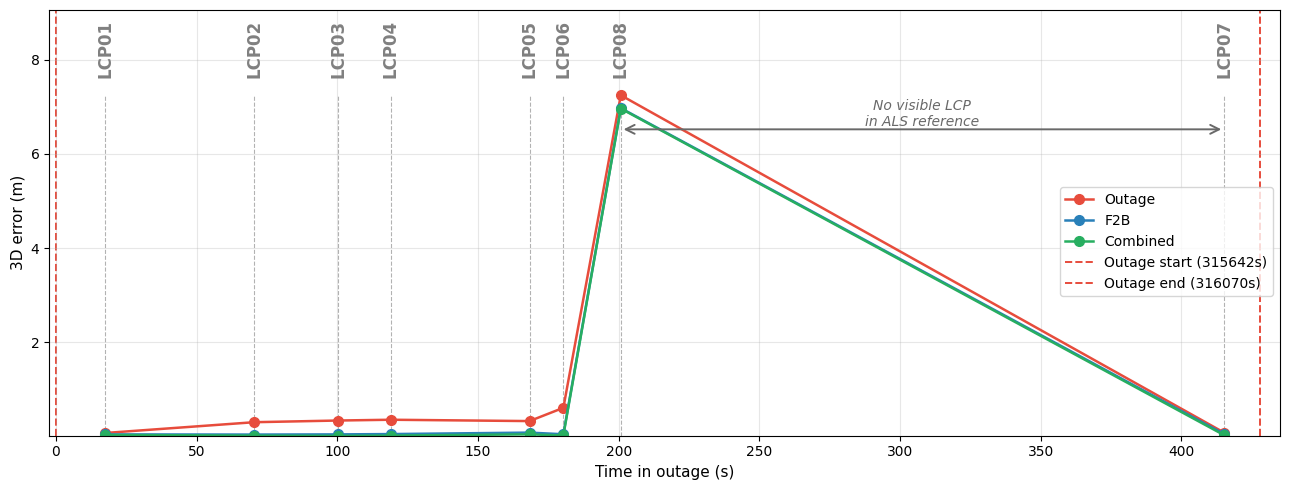


--- Summary ---
  Outage      RMSE=2.5821m   Max=7.2482m (LCP08)
  F2B         RMSE=2.4662m   Max=6.9744m (LCP08)
  Combined    RMSE=2.4625m   Max=6.9649m (LCP08)


In [6]:
# ==============================================================
# Cell 6 — Visualisation erreur 3D vs temps dans l'outage
# ==============================================================
T_OUTAGE_START_GPS = 315642.0
T_OUTAGE_END_GPS   = 316070.0
T_OUTAGE_DUR       = T_OUTAGE_END_GPS - T_OUTAGE_START_GPS
COLORS = {"Outage": "#e74c3c", "F2B": "#2980b9", "Combined": "#27ae60"}
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(13, 5))

# --- Courbes ---
for label, df_match in df_match_all.items():
    df_plot = df_match.dropna(subset=["dist_3d"]).copy()
    df_plot["t_in_outage"] = df_plot["gps_time"] - T_OUTAGE_START_GPS
    df_plot = df_plot.sort_values("t_in_outage")
    ax.plot(df_plot["t_in_outage"], df_plot["dist_3d"],
            "o-", color=COLORS[label], linewidth=1.8, markersize=7, label=label)
    # for i, row in df_plot.iterrows():
    #     ax.annotate(i, (row["t_in_outage"], row["dist_3d"]),
    #                 textcoords="offset points", xytext=(5, 5), fontsize=8,
    #                 color=COLORS[label])

# --- ylim ---
y_max = max(
    df_match.dropna(subset=["dist_3d"])["dist_3d"].max()
    for df_match in df_match_all.values()
)
Y_TOP      = y_max * 1.25
Y_LINE_TOP = y_max * 1.0
Y_TEXT     = Y_LINE_TOP * 1.05
ax.set_ylim(bottom=0.01, top=Y_TOP)

# --- Lignes verticales grises par LCP ---
first_label = list(df_match_all.keys())[0]
df_lcp = df_match_all[first_label].dropna(subset=["dist_3d"]).copy()
df_lcp["t_in_outage"] = df_lcp["gps_time"] - T_OUTAGE_START_GPS
df_lcp = df_lcp.sort_values("t_in_outage")

lcp_times = df_lcp["t_in_outage"].values
lcp_names = df_lcp.index.tolist()

for lcp_name, t in zip(lcp_names, lcp_times):
    ax.plot([t, t], [0, Y_LINE_TOP],
            color="grey", linewidth=0.8, linestyle="--", alpha=0.6, zorder=0)
    ax.text(t, Y_TEXT, lcp_name,
            rotation=90, fontsize=12, color="grey",
            ha="center", va="bottom", fontweight="bold")

# --- Double flèche "No visible LCP in LAS data" entre avant-dernier et dernier LCP ---
if len(lcp_times) >= 2:
    t_start_arrow = lcp_times[-2]
    t_end_arrow   = lcp_times[-1]
    t_mid_arrow   = (t_start_arrow + t_end_arrow) / 2
    y_arrow       = Y_LINE_TOP * 0.9

    ax.annotate("", xy=(t_end_arrow, y_arrow), xytext=(t_start_arrow, y_arrow),
                arrowprops=dict(arrowstyle="<->", color="dimgrey",
                                lw=1.4, mutation_scale=16))
    ax.text(t_mid_arrow, y_arrow + 0.012,
            "No visible LCP\nin ALS reference",
            ha="center", va="bottom", fontsize=10,
            color="dimgrey", style="italic")

# --- Début et fin outage en rouge ---
ax.axvline(x=0,            color="#e74c3c", linewidth=1.4, linestyle="--",
           label=f"Outage start ({T_OUTAGE_START_GPS:.0f}s)", zorder=1)
ax.axvline(x=T_OUTAGE_DUR, color="#e74c3c", linewidth=1.4, linestyle="--",
           label=f"Outage end ({T_OUTAGE_END_GPS:.0f}s)", zorder=1)

ax.set_xlabel("Time in outage (s)", fontsize=11)
ax.set_ylabel("3D error (m)", fontsize=11)
ax.legend(fontsize=10, loc="upper right",
          bbox_to_anchor=(1.0, 0.60))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/home/b085164/PDM_Romain_Defferrard/LCP_APX_Z3_ECCR.png", dpi=400)
plt.show()

# --- Tableau récap ---
print("\n--- Summary ---")
for label, df_match in df_match_all.items():
    df_plot = df_match.dropna(subset=["dist_3d"])
    rmse  = np.sqrt((df_plot["dist_3d"]**2).mean())
    max_e = df_plot["dist_3d"].max()
    print(f"  {label:10s}  RMSE={rmse:.4f}m   Max={max_e:.4f}m ({df_plot['dist_3d'].idxmax()})")